In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, QuantileTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [20]:
df = pd.read_csv("drawndata1.csv")
df.head(3)

,x,y,z
0,434.709229,626.669460,a
1,921.851828,262.900837,b
2,1103.548213,427.310313,b


In [21]:
X = df[["x", "y"]].values
Y = df["z"] == "a"
# X_new = StandardScaler().fit_transform(X)
# X_new = QuantileTransformer(n_quantiles=10).fit_transform(X)

In [22]:
def plot_output(scaler):
    # 1. Load data
    df = pd.read_csv("drawndata1.csv")
    X = df[["x", "y"]].values
    y = (df["z"] == "a").astype(int)

    # 2. Apply scaler
    X_scaled = scaler.fit_transform(X)

    # 3. Train a simple model (probably logistic regression)
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression().fit(X_scaled, y)

    # 4. Predict on scaled data
    y_pred = model.predict_proba(X_scaled)[:, 1] 

    # 5. Plot everything
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].scatter(X[:,0], X[:,1], c=y)
    axs[0].set_title("Original Data")

    axs[1].scatter(X_scaled[:,0], X_scaled[:,1], c=y)
    axs[1].set_title("Transformed Data")

    axs[2].scatter(X[:,0], X[:,1], c=y_pred)
    axs[2].set_title("Predicted Data")

    plt.show()


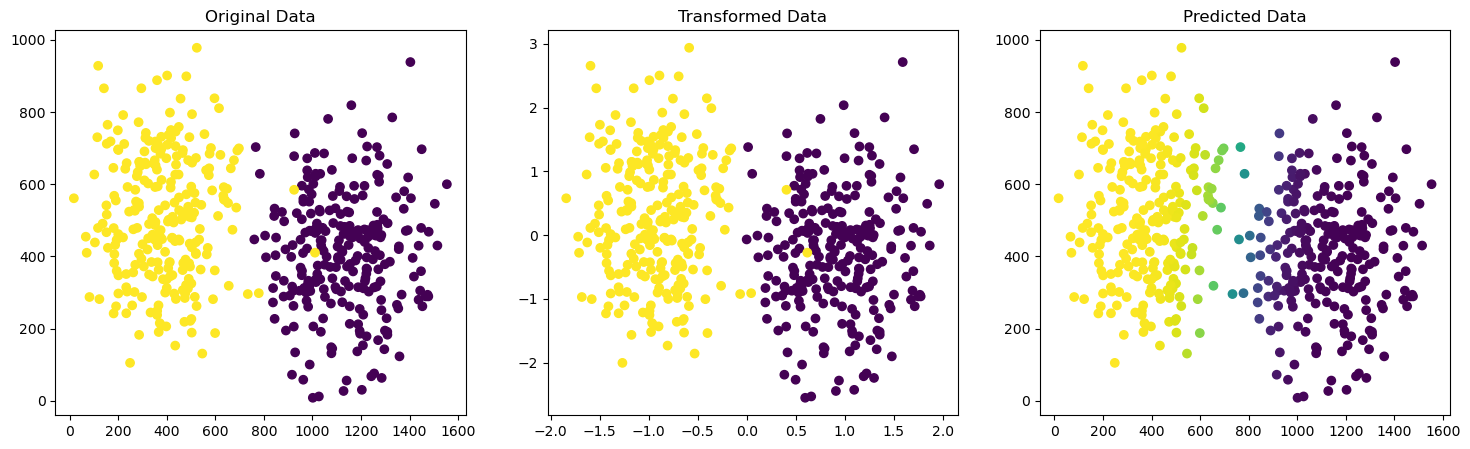

In [23]:
plot_output(scaler=StandardScaler())

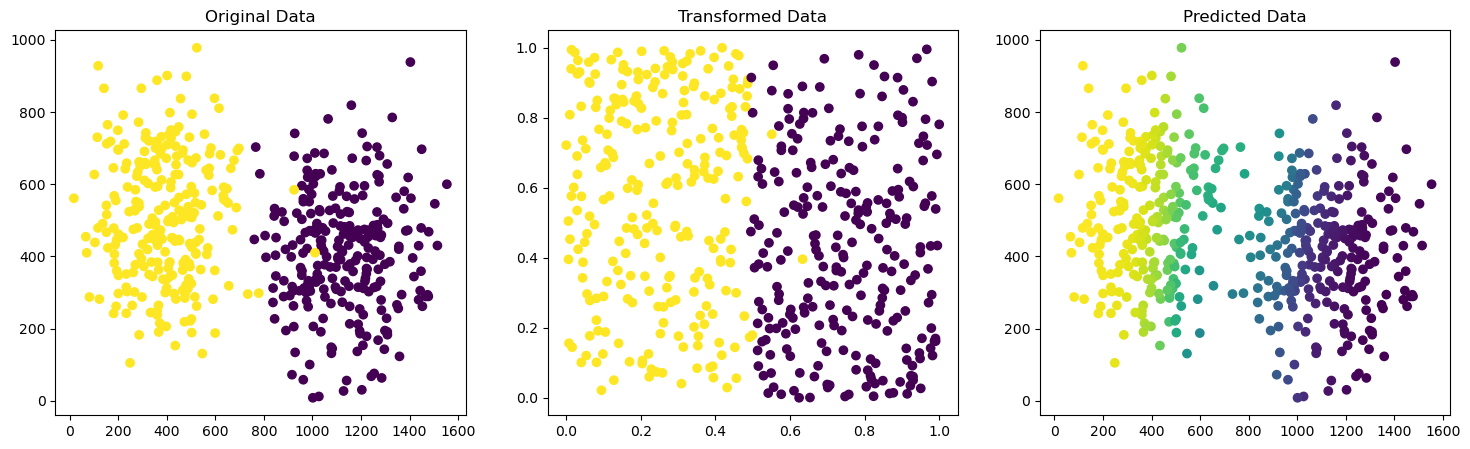

In [24]:
plot_output(scaler=QuantileTransformer(n_quantiles=100))

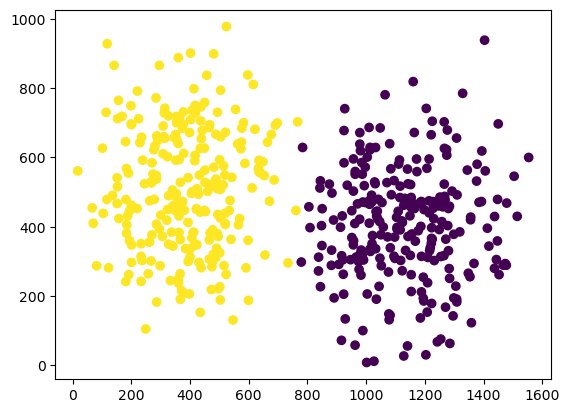

In [26]:
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("scale", PolynomialFeatures()),
     ("model", LogisticRegression())
])

pred = pipe.fit(X,Y).predict(X)
plt.scatter(X[:,0], X[:,1], c=pred);

#2 transforming text data into numeric data so that the sklearn can use it to train model

In [28]:
arr = np.array(["low", "low", "high", "medium"]).reshape(-1,1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [33]:
enc.transform([["zero"]])

array([[0., 0., 0.]])